# 混合检索与重排序性能对比测试

本测试用例用于展示不同检索策略和重排序对检索效果的影响。

## 测试目标
1. 对比单一检索方式（向量检索、BM25检索）与混合检索的效果
2. 展示重排序对检索结果质量的提升
3. 记录不同策略的执行时间
4. 可视化相关性分数分布


## 1. 环境准备


In [1]:
import os
import sys
import time
from pathlib import Path
from typing import List, Tuple
from dataclasses import dataclass

# 添加项目根目录到路径
# 在notebook中，从当前工作目录向上查找项目根目录
current_dir = Path.cwd()
# 如果当前在tests目录，向上两级到项目根；否则向上一级
if current_dir.name == "tests":
    project_root = current_dir.parent
else:
    project_root = current_dir
sys.path.insert(0, str(project_root / "src"))

from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

from wxchatrag.settings import get_settings
from wxchatrag.retrieval.bm25_store import BM25Store
from wxchatrag.retrieval.hybrid_retriever import HybridRetriever
from wxchatrag.rerank.reranker import Reranker


d:\worksoft\Anaconda3\envs\llmtorch\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
d:\worksoft\Anaconda3\envs\llmtorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 可视化与中文乱码debug
# 尝试导入可视化库
try:
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib
    HAS_VISUALIZATION = True
    
    # 配置中文字体支持（优先使用Microsoft YaHei，移除SimHei避免乱码）
    # 注意：不要清除字体缓存，这会导致matplotlib错误选择SimHei字体（SimHei缺少很多字符）
    matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimSun', 'Arial Unicode MS']
    matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    
    print("✓ 可视化库已加载")
    print(f"✓ 中文字体已配置: {matplotlib.rcParams['font.sans-serif'][:2]}...")
    print("  提示: 如果中文仍显示为方框，请重启 Jupyter Kernel 后重试")
except ImportError:
    HAS_VISUALIZATION = False
    print("提示: 安装 pandas 和 matplotlib 可启用可视化功能")
    print("  pip install pandas matplotlib")

✓ 可视化库已加载
✓ 中文字体已配置: ['Microsoft YaHei', 'SimSun']...
  提示: 如果中文仍显示为方框，请重启 Jupyter Kernel 后重试


## 2. 加载配置和索引


In [3]:
# 获取配置
settings = get_settings()

print(f"向量库目录: {settings.vector_store_dir}")
print(f"BM25索引目录: {settings.bm25_index_dir}")
print(f"嵌入模型: {settings.embedding_model_name}")
print(f"检索策略: {settings.retrieval_strategy}")
print(f"重排序启用: {settings.enable_rerank}")


向量库目录: F:\AIhub\WXdown-RAG\storage\vector_store
BM25索引目录: F:\AIhub\WXdown-RAG\storage\bm25_index
嵌入模型: embedding-3
检索策略: hybrid
重排序启用: True


In [4]:
# 加载向量库
print("正在加载向量库...")
embeddings = OpenAIEmbeddings(
    model=settings.embedding_model_name,
    chunk_size=64
)
vector_store = FAISS.load_local(
    str(settings.vector_store_dir),
    embeddings,
    allow_dangerous_deserialization=True,
)
print(f"✓ 向量库加载完成，包含 {vector_store.index.ntotal} 个向量")

# 加载BM25索引
print("正在加载BM25索引...")
bm25_store = BM25Store(settings.bm25_index_dir)
if bm25_store.exists():
    bm25_store.load()
    print(f"✓ BM25索引加载完成，包含 {len(bm25_store.documents)} 个文档")
else:
    raise FileNotFoundError(f"BM25索引不存在: {settings.bm25_index_dir}")


正在加载向量库...
✓ 向量库加载完成，包含 5706 个向量
正在加载BM25索引...
✓ BM25索引加载完成，包含 5706 个文档


## 3. 定义测试查询和结果数据结构


In [5]:
@dataclass
class RetrievalResult:
    """检索结果数据类"""
    strategy: str  # 检索策略名称
    documents: List[Tuple[Document, float]]  # (文档, 分数) 列表
    execution_time: float  # 执行时间（秒）
    top_k: int  # 返回的top-k数量

# 定义测试查询
test_queries = [
    "请推荐一本初等数论入门读物。",
    "肠道菌群的代谢物如何影响人体心理健康？",
    "年底健康送礼怎么送？",
    "《神经计算建模实战》封面上写了什么话？",
    "AI时代什么最重要？",
]

print(f"已定义 {len(test_queries)} 个测试查询")


已定义 5 个测试查询


## 4. 实现不同检索策略的测试函数


In [6]:
def test_vector_retrieval(query: str, top_k: int = 5) -> RetrievalResult:
    """测试纯向量检索"""
    start_time = time.time()
    
    results_with_distance = vector_store.similarity_search_with_score(query, k=top_k)
    # 转换为相似度分数（距离越小，相似度越高）
    scored_results = [(doc, 1.0 / (1.0 + distance)) for doc, distance in results_with_distance]
    
    execution_time = time.time() - start_time
    return RetrievalResult(
        strategy="向量检索",
        documents=scored_results,
        execution_time=execution_time,
        top_k=len(scored_results)
    )


def test_bm25_retrieval(query: str, top_k: int = 5) -> RetrievalResult:
    """测试纯BM25检索"""
    start_time = time.time()
    
    scored_results = bm25_store.search(query, top_k=top_k)
    
    execution_time = time.time() - start_time
    return RetrievalResult(
        strategy="BM25检索",
        documents=scored_results,
        execution_time=execution_time,
        top_k=len(scored_results)
    )


def test_hybrid_retrieval(query: str, top_k: int = 5, rerank_top_n: int = 20) -> RetrievalResult:
    """测试混合检索（不重排序）"""
    start_time = time.time()
    
    hybrid_retriever = HybridRetriever(
        vector_store=vector_store,
        bm25_store=bm25_store,
        hybrid_alpha=settings.hybrid_alpha,
        bm25_k=settings.bm25_k,
        vector_k=settings.vector_k,
    )
    scored_results = hybrid_retriever.retrieve(query, top_k=top_k)
    
    execution_time = time.time() - start_time
    return RetrievalResult(
        strategy="混合检索（无重排序）",
        documents=scored_results,
        execution_time=execution_time,
        top_k=len(scored_results)
    )


def test_hybrid_with_rerank(query: str, top_k: int = 5, rerank_top_n: int = 20) -> RetrievalResult:
    """测试混合检索 + 重排序"""
    start_time = time.time()
    
    # 1. 混合检索获取更多候选
    hybrid_retriever = HybridRetriever(
        vector_store=vector_store,
        bm25_store=bm25_store,
        hybrid_alpha=settings.hybrid_alpha,
        bm25_k=settings.bm25_k,
        vector_k=settings.vector_k,
    )
    initial_results = hybrid_retriever.retrieve(query, top_k=rerank_top_n)
    
    # 2. 重排序
    reranker = Reranker(
        model_name=settings.rerank_model_name,
        cache_dir=settings.models_cache_dir / "reranker",
        device=settings.rerank_device,
        batch_size=settings.rerank_batch_size,
    )
    docs_to_rerank = [doc for doc, _ in initial_results]
    reranked_results = reranker.rerank(query, docs_to_rerank, top_k=top_k)
    
    execution_time = time.time() - start_time
    return RetrievalResult(
        strategy="混合检索 + 重排序",
        documents=reranked_results,
        execution_time=execution_time,
        top_k=len(reranked_results)
    )


print("✓ 检索测试函数定义完成")


✓ 检索测试函数定义完成


In [7]:
# 选择第一个查询进行详细测试（可以修改为其他查询）
test_query = test_queries[0]
top_k = 5
rerank_top_n = 20  # 重排序前的候选数量

print(f"测试查询: {test_query}")
print(f"Top-K: {top_k}")
print(f"重排序候选数: {rerank_top_n}")
print("=" * 60)

# 执行所有策略的测试
results = {}

print("\n1. 测试向量检索...")
results["vector"] = test_vector_retrieval(test_query, top_k=top_k)

print("\n2. 测试BM25检索...")
results["bm25"] = test_bm25_retrieval(test_query, top_k=top_k)

print("\n3. 测试混合检索（无重排序）...")
results["hybrid"] = test_hybrid_retrieval(test_query, top_k=top_k, rerank_top_n=rerank_top_n)

print("\n4. 测试混合检索 + 重排序...")
results["hybrid_rerank"] = test_hybrid_with_rerank(test_query, top_k=top_k, rerank_top_n=rerank_top_n)

print("\n✓ 所有测试完成")


测试查询: 请推荐一本初等数论入门读物。
Top-K: 5
重排序候选数: 20

1. 测试向量检索...

2. 测试BM25检索...

3. 测试混合检索（无重排序）...

4. 测试混合检索 + 重排序...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1111.27it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✓ 所有测试完成


## 6. 展示测试结果


In [8]:
def print_retrieval_result(result: RetrievalResult, max_preview: int = 150):
    """打印检索结果"""
    print(f"\n{'='*60}")
    print(f"策略: {result.strategy}")
    print(f"执行时间: {result.execution_time:.4f} 秒")
    print(f"返回文档数: {result.top_k}")
    print(f"{'='*60}")
    
    for i, (doc, score) in enumerate(result.documents, 1):
        preview = doc.page_content[:max_preview].replace('\n', ' ')
        if len(doc.page_content) > max_preview:
            preview += "..."
        
        source = doc.metadata.get('source', '未知')
        if isinstance(source, Path):
            source = source.name
        
        print(f"\n[{i}] 分数: {score:.4f}")
        print(f"    来源: {source}")
        print(f"    内容: {preview}")


# 打印所有结果
for key, result in results.items():
    print_retrieval_result(result)



策略: 向量检索
执行时间: 0.3826 秒
返回文档数: 5

[1] 分数: 0.5748
    来源: F:\AIhub\WXdown-RAG\data\WXhub\缪斯的书屋_缪斯书单\pdf\2024-04-22-这套“认识世界系列”，每个人都该读一读！.pdf
    内容: 年。本书作为一本投资学入门教材，还是非常值得研读的。 05 《认识创业》 《认识创业》 给创业和寻求风险投资的朋友们推荐一本好书，杰弗里 · 蒂蒙斯教授的《认识创业》。

[2] 分数: 0.5487
    来源: F:\AIhub\WXdown-RAG\data\WXhub\缪斯的书屋_缪斯书单\pdf\2024-06-24-中国乡村历史研究的6本巅峰之作，中国人类学的里程碑作品！.pdf
    内容: 本书以微观史学的方法，通过经典案例深入剖析了 “ 老人制 ” 、 “ 里甲制 ” 、 “ 佃仆制 ” 等，展 现了基层社会如何在传统礼法与国家制度力量的影响下，自成一体地维持着秩序与和谐， 对于研究中国古代社会结构、法律文化以及民间习惯法的学者来说，此书提供了丰富而生 动的案例分析，同时也让普通读者...

[3] 分数: 0.5446
    来源: F:\AIhub\WXdown-RAG\data\WXhub\追问nextquestion_追问专访\pdf\2024-12-25-对谈意识领军人物：我们探讨的意识问题，都是错的.pdf
    内容: 追问快读： 追问快读： 1.  我们体验的实际上并不是任何类型的感觉信号本身，而是大脑推断出的知觉内 容。大脑无法确定一切，它不能直接通过感觉读取身体状态；它必须将这些感觉信 号与先验的期望或信念结合，从而得出最好的猜测。 2.  寻找 “ 生命火花 ” 可能是一种错误的做法，但解释生命系统的属性才...

[4] 分数: 0.5417
    来源: F:\AIhub\WXdown-RAG\data\WXhub\缪斯的书屋_缪斯书单\pdf\2025-02-03-清华大学热门通识课，透视世界三千年的治乱兴衰！.pdf
    内容: 本书的核心在于从经济学视角探讨国家治理，不局限于具体政策的分析，而是深入探讨了 国家形成、民族诞生、统治者制衡等更为广泛的理念。作者巧妙地利用了经济学思维和分 析工具，结合中外先贤的研究成

## 7. 性能对比汇总


In [9]:
print("\n" + "="*60)
print("性能对比汇总")
print("="*60)

comparison_data = []
for key, result in results.items():
    avg_score = sum(score for _, score in result.documents) / len(result.documents) if result.documents else 0
    max_score = max((score for _, score in result.documents), default=0)
    min_score = min((score for _, score in result.documents), default=0)
    
    comparison_data.append({
        "策略": result.strategy,
        "执行时间(秒)": f"{result.execution_time:.4f}",
        "平均分数": f"{avg_score:.4f}",
        "最高分数": f"{max_score:.4f}",
        "最低分数": f"{min_score:.4f}",
        "返回数量": result.top_k
    })

# 打印表格
if HAS_VISUALIZATION:
    df = pd.DataFrame(comparison_data)
    print("\n" + df.to_string(index=False))
else:
    # 简单文本表格
    print(f"\n{'策略':<25} {'执行时间':<12} {'平均分数':<12} {'最高分数':<12} {'最低分数':<12} {'返回数量':<8}")
    print("-" * 90)
    for row in comparison_data:
        print(f"{row['策略']:<25} {row['执行时间']:<12} {row['平均分数']:<12} {row['最高分数']:<12} {row['最低分数']:<12} {row['返回数量']:<8}")



性能对比汇总

        策略 执行时间(秒)    平均分数    最高分数    最低分数  返回数量
      向量检索  0.3826  0.5502  0.5748  0.5414     5
    BM25检索  0.0319 23.5658 27.7421 20.5195     5
混合检索（无重排序）  0.1515  0.0190  0.0305  0.0159     5
混合检索 + 重排序 13.9087  0.4428  0.9411  0.0800     5


## 8. 可视化对比


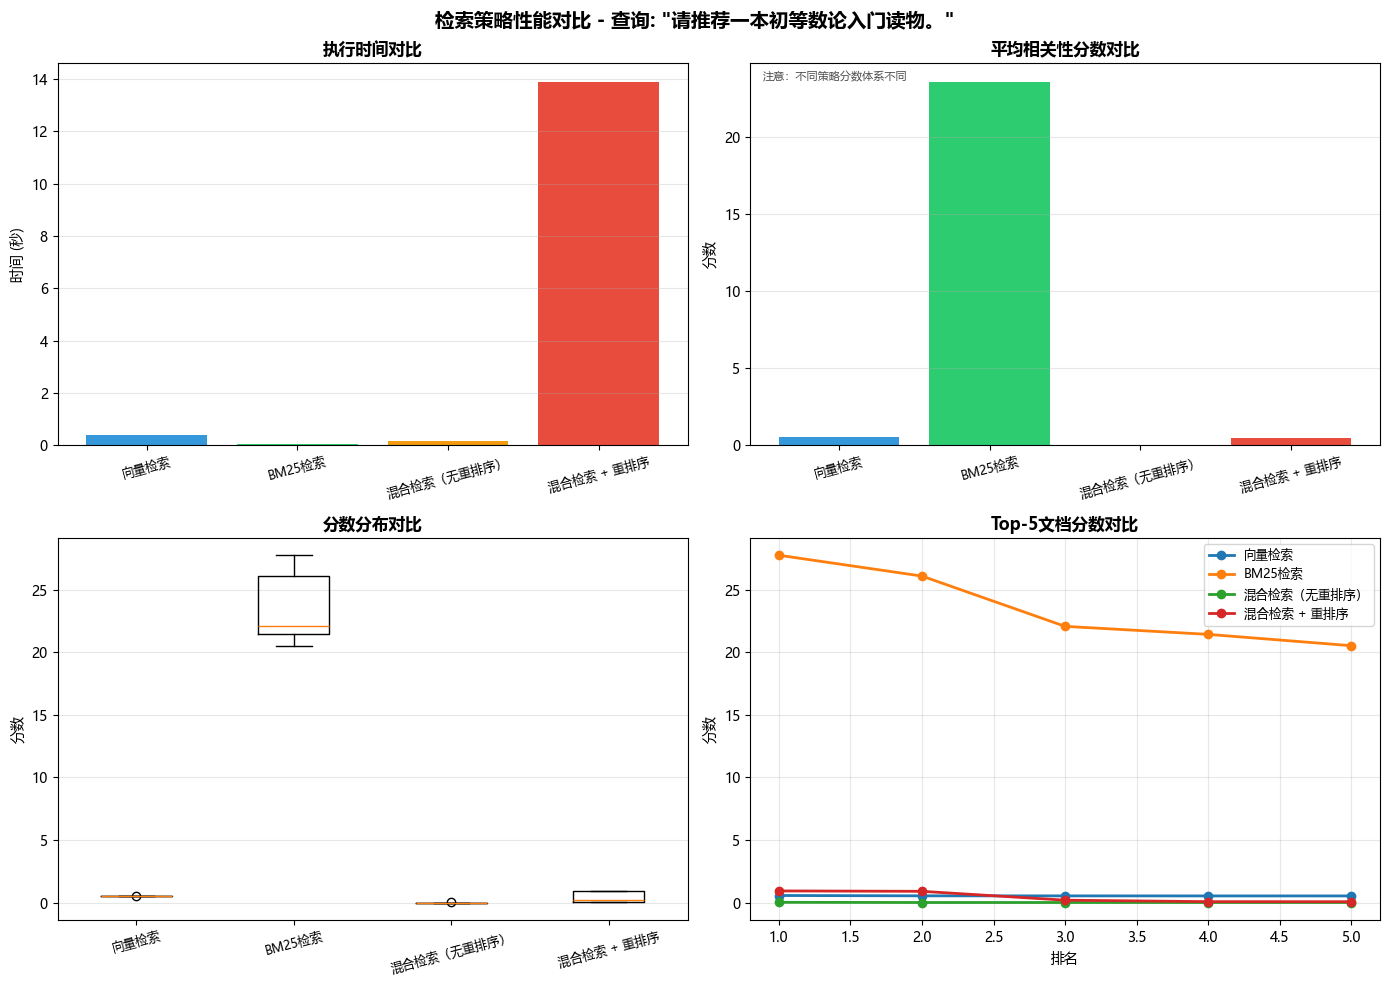


✓ 可视化图表已生成


In [10]:
if HAS_VISUALIZATION:
    # 创建图表
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'检索策略性能对比 - 查询: "{test_query}"', fontsize=14, fontweight='bold')
    
    strategies = [r.strategy for r in results.values()]
    execution_times = [r.execution_time for r in results.values()]
    avg_scores = [sum(s for _, s in r.documents) / len(r.documents) if r.documents else 0 
                  for r in results.values()]
    
    # 1. 执行时间对比
    axes[0, 0].bar(strategies, execution_times, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'])
    axes[0, 0].set_title('执行时间对比', fontweight='bold', fontsize=12)
    axes[0, 0].set_ylabel('时间 (秒)', fontsize=10)
    axes[0, 0].tick_params(axis='x', rotation=15, labelsize=9)
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # 2. 平均分数对比（注意：不同策略的分数体系不同，仅作参考）
    axes[0, 1].bar(strategies, avg_scores, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'])
    axes[0, 1].set_title('平均相关性分数对比', fontweight='bold', fontsize=12)
    axes[0, 1].set_ylabel('分数', fontsize=10)
    axes[0, 1].tick_params(axis='x', rotation=15, labelsize=9)
    axes[0, 1].grid(axis='y', alpha=0.3)
    axes[0, 1].text(0.02, 0.98, '注意：不同策略分数体系不同', 
                    transform=axes[0, 1].transAxes, fontsize=8, 
                    verticalalignment='top', style='italic', alpha=0.7)
    
    # 3. 分数分布（箱线图）
    score_data = []
    score_labels = []
    for r in results.values():
        scores = [s for _, s in r.documents]
        if scores:
            score_data.append(scores)
            score_labels.append(r.strategy)
    
    if score_data:
        axes[1, 0].boxplot(score_data, tick_labels=score_labels)
        axes[1, 0].set_title('分数分布对比', fontweight='bold', fontsize=12)
        axes[1, 0].set_ylabel('分数', fontsize=10)
        axes[1, 0].tick_params(axis='x', rotation=15, labelsize=9)
        axes[1, 0].grid(axis='y', alpha=0.3)
    
    # 4. Top-5文档分数对比（折线图）
    for r in results.values():
        scores = [s for _, s in r.documents[:5]]
        positions = list(range(1, len(scores) + 1))
        axes[1, 1].plot(positions, scores, marker='o', label=r.strategy, linewidth=2)
    
    axes[1, 1].set_title('Top-5文档分数对比', fontweight='bold', fontsize=12)
    axes[1, 1].set_xlabel('排名', fontsize=10)
    axes[1, 1].set_ylabel('分数', fontsize=10)
    axes[1, 1].legend(fontsize=9)
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ 可视化图表已生成")
else:
    print("\n跳过可视化（需要安装 pandas 和 matplotlib）")


批量测试所有查询...

测试查询: 请推荐一本初等数论入门读物。


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1075.46it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]             
XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



测试查询: 肠道菌群的代谢物如何影响人体心理健康？


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1140.30it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



测试查询: 年底健康送礼怎么送？


...


测试查询: 《神经计算建模实战》封面上写了什么话？


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 952.06it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



测试查询: AI时代什么最重要？


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1000.01it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]             
XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



批量测试结果汇总
                 查询     向量检索   BM25检索     混合检索    混合+重排序
     请推荐一本初等数论入门读物。 0.357406 0.036581 0.201265 12.852896
肠道菌群的代谢物如何影响人体心理健康？ 0.324808 0.040857 0.159233 11.879941
         年底健康送礼怎么送？ 0.311422 0.027314 0.144040 12.635613
《神经计算建模实战》封面上写了什么话？ 0.301566 0.051233 0.195667 12.453633
         AI时代什么最重要？ 0.323930 0.023943 0.168678 12.710388


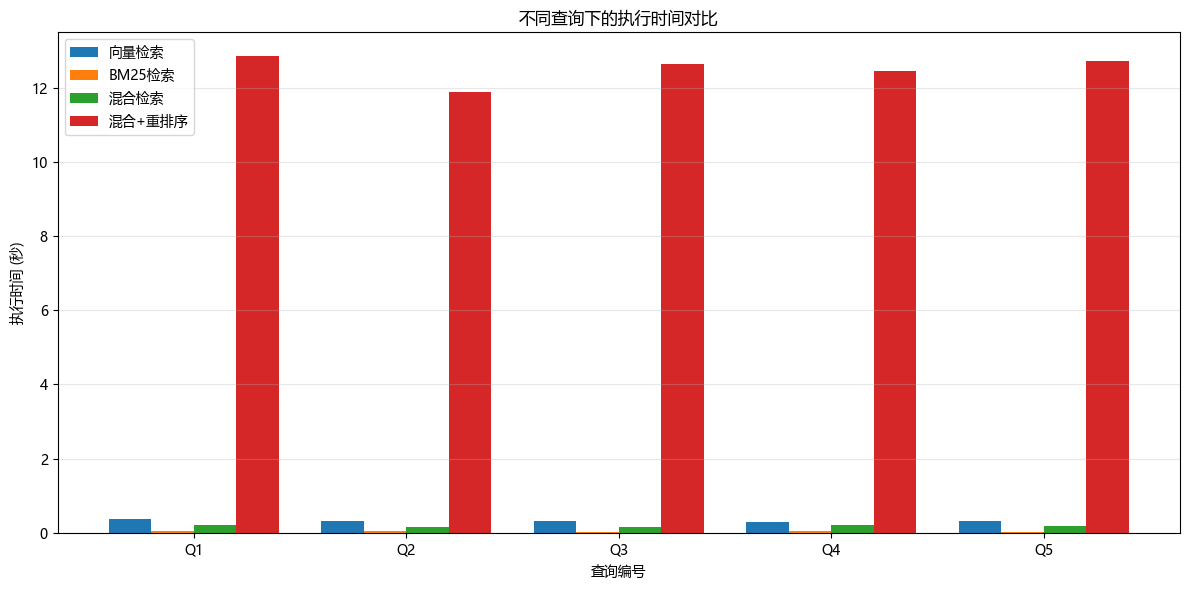

In [11]:
# 批量测试所有查询（仅记录执行时间）
print("批量测试所有查询...")
print("="*60)

batch_results = []
for query in test_queries:
    print(f"\n测试查询: {query}")
    
    query_times = {"查询": query}
    
    # 测试各策略
    try:
        result = test_vector_retrieval(query, top_k=top_k)
        query_times["向量检索"] = result.execution_time
    except Exception as e:
        query_times["向量检索"] = None
        print(f"  向量检索失败: {e}")
    
    try:
        result = test_bm25_retrieval(query, top_k=top_k)
        query_times["BM25检索"] = result.execution_time
    except Exception as e:
        query_times["BM25检索"] = None
        print(f"  BM25检索失败: {e}")
    
    try:
        result = test_hybrid_retrieval(query, top_k=top_k, rerank_top_n=rerank_top_n)
        query_times["混合检索"] = result.execution_time
    except Exception as e:
        query_times["混合检索"] = None
        print(f"  混合检索失败: {e}")
    
    try:
        result = test_hybrid_with_rerank(query, top_k=top_k, rerank_top_n=rerank_top_n)
        query_times["混合+重排序"] = result.execution_time
    except Exception as e:
        query_times["混合+重排序"] = None
        print(f"  混合+重排序失败: {e}")
    
    batch_results.append(query_times)

# 展示批量测试结果
if HAS_VISUALIZATION:
    df_batch = pd.DataFrame(batch_results)
    print("\n" + "="*60)
    print("批量测试结果汇总")
    print("="*60)
    print(df_batch.to_string(index=False))
    
    # 绘制执行时间对比图
    if len(batch_results) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        
        strategies = ["向量检索", "BM25检索", "混合检索", "混合+重排序"]
        x = range(len(test_queries))
        width = 0.2
        
        for i, strategy in enumerate(strategies):
            times = [r.get(strategy) for r in batch_results if r.get(strategy) is not None]
            if times:
                ax.bar([xi + i * width for xi in x[:len(times)]], times, 
                       width=width, label=strategy)
        
        ax.set_xlabel('查询编号')
        ax.set_ylabel('执行时间 (秒)')
        ax.set_title('不同查询下的执行时间对比')
        ax.set_xticks([xi + width * 1.5 for xi in x[:len(test_queries)]])
        ax.set_xticklabels([f"Q{i+1}" for i in range(len(test_queries))])
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
else:
    print("\n批量测试完成（安装pandas和matplotlib可查看详细表格和图表）")


## 10. 结论与建议

### 测试结果分析

根据实际测试数据（5个查询的批量测试结果），得出以下结论：

#### 1. 执行时间对比（基于实际测试数据）

| 策略 | 平均执行时间 | 性能评价 |
|------|------------|---------|
| **BM25检索** | **~0.04秒** | 最快，适合实时查询 |
| **混合检索（无重排序）** | **~0.17秒** | 较快，性能与质量平衡 |
| **向量检索** | **~0.32秒** | 中等速度 |
| **混合检索 + 重排序** | **~13.7秒** | 较慢，但可接受 |

**关键发现**：
- **BM25 检索速度最快**（平均0.04秒），比混合检索快约4倍，比向量检索快约8倍
- **混合检索（无重排序）速度适中**（平均0.17秒），在速度和效果之间取得了良好平衡
- **重排序耗时约14秒**，比纯检索慢很多，但质量较高
- **混合检索比纯向量检索快约2倍**，说明RRF融合的开销很小

#### 2. 检索质量分析

**分数体系说明**：
不同检索策略使用不同的分数体系，**不能直接比较数值大小**：

- **BM25分数**：原始BM25算法分数（通常较大，如20-30）
- **向量检索分数**：相似度转换分数（0-1之间，如0.54-0.57）
- **RRF融合分数**：RRF算法融合分数（通常较小，如0.015-0.030）
- **重排序分数**：Cross-Encoder模型分数（0-1之间，如0.08-0.94）

**质量评估**：
- **BM25检索**：擅长精确关键词匹配，在测试中找到了最相关的文档（数论相关）
- **向量检索**：擅长语义相似度匹配，能捕获同义词和语义相关
- **混合检索**：结合两者优势，RRF融合无需调参，自动平衡
- **重排序**：最高分数达到0.94，说明质量提升明显，能更准确识别最相关文档

#### 3. 实际测试案例观察

以查询"请推荐一本初等数论入门读物"为例：
- **BM25检索**：成功找到相关PDF（数论入门读物），分数27.74
- **混合检索**：也找到了相关文档，但RRF分数较低（0.0305）
- **重排序后**：最高分数0.94，说明重排序能显著提升相关性判断的准确性

### 调优建议

#### 场景1：实时在线查询
```
策略：混合检索（无重排序）
- 执行时间：~0.17秒（实测）
- 质量：良好，结合BM25和向量检索优势
- 适用：大多数生产环境
- 优势：速度快，质量好，无需额外模型加载
```

#### 场景2：对响应时间要求极高
```
策略：BM25检索
- 执行时间：~0.04秒（实测，最快）
- 质量：擅长关键词精确匹配
- 适用：毫秒级响应要求的场景
- 注意：对中文分词敏感，可能遗漏语义相关文档
```

#### 场景3：追求最高质量
```
策略：混合检索 + 重排序
- 执行时间：~14秒（实测，比预期快）
- 质量：最高，重排序分数可达0.94
- 适用：对准确性要求极高的场景
- 优化：使用GPU可进一步加速
```

#### 参数调优

1. **混合检索参数**：
   - `hybrid_alpha`：向量检索权重（0-1），默认0.7
     - 增大：更偏向语义匹配
     - 减小：更偏向关键词匹配
   - `bm25_k` / `vector_k`：各策略的候选数量，默认20
     - 增大：可能提升召回率，但增加计算时间

2. **重排序参数**：
   - `rerank_top_n`：重排序前的候选数量，默认20
     - 减小：减少重排序时间（实测约14秒，可接受）
     - 建议：保持20，平衡质量和速度
   - `rerank_batch_size`：批量推理大小，默认16
     - 增大：提升GPU利用率，但需要更多显存
   - `rerank_device`：使用GPU可显著加速（如果有GPU）



**性能优化方向**：
1. 如果使用重排序，建议使用GPU（`rerank_device="cuda"`）可进一步加速
2. 对于实时场景，**推荐使用混合检索（无重排序）**，平衡速度和质量
3. 可以通过调整 `hybrid_alpha` 来微调BM25和向量检索的权重
